<h1><b>SHM Fatigue Damage Data Preprocessing</b></h1>

<h4><b>Background Information</b></h4>

The SHM subsystem in NEBULA X Problem Statement 3 estimates the cumulative fatigue damage of a
structure from dynamic-stress recordings. The information kit describes the reference damage as the
result of rainflow cycle counting combined with Miner's rule, and predictions are scored by
`max(0, 1 - MAPE)`. The SHM exploratory data analysis found clean, equal-length recordings, a roughly
32-fold damage range, and a strong association between damage and peak-to-peak stress.

<h4><b>Objective</b></h4>

This notebook turns the 80 raw recordings into validated, model-ready tables. It audits every
recording, counts rainflow cycles without any prior filtering, verifies the cycle counts, builds
damage-sum features for a range of S-N exponents together with range-distribution and signal
statistics, compares Train and Test coverage, assigns damage-band folds, and saves the cycle tables and
features. No model is trained and no Test damage is inferred.

<h4><b>Project Workflow</b></h4>

The workflow configures the environment, inventories the recordings and labels, and loads the
headerless files. It validates dimensions, types, missing and non-finite values, duplicates, value
resolution, ranges, distributions and the target. It then extracts and verifies rainflow cycles,
constructs features, screens their association with damage, compares Train and Test, assigns folds,
and exports the results with a manifest.

<h4><b>Dataset Used</b></h4>

`PS3/02_Datasets/SHM` contains 64 labelled Train recordings (`train01.csv` to `train64.csv`), 16
unlabelled Test recordings (`test01.csv` to `test16.csv`) and `Train_Labels.csv` with one damage value
per Train file. Each recording is a single headerless column of stress values. The sampling rate,
stress units and S-N constants are not supplied. Outputs are written to `data/processed/shm`, which is
excluded from version control.

<h4><b>Table of Contents</b></h4>
<ul>
  <li><a href="#section-1">Section 1: Environment Setup and Configuration</a>
    <ul>
      <li><a href="#1-1">1.1 Libraries and Display Settings</a></li>
      <li><a href="#1-2">1.2 Dataset Location and Output Directory</a></li>
      <li><a href="#1-3">1.3 Environment Versions</a></li>
    </ul>
  </li>
  <li><a href="#section-2">Section 2: Data Loading and Inventory</a>
    <ul>
      <li><a href="#2-1">2.1 File Inventory</a></li>
      <li><a href="#2-2">2.2 Label Loading and Coverage</a></li>
      <li><a href="#2-3">2.3 Headerless Recording Loading</a></li>
    </ul>
  </li>
  <li><a href="#section-3">Section 3: Data Inspection and Validation</a>
    <ul>
      <li><a href="#3-1">3.1 Dimensions and Data Types</a></li>
      <li><a href="#3-2">3.2 Missing, Non-Finite and Constant Recordings</a></li>
      <li><a href="#3-3">3.3 Duplicate Recordings</a></li>
      <li><a href="#3-4">3.4 Value Resolution</a></li>
      <li><a href="#3-5">3.5 Value Ranges</a></li>
      <li><a href="#3-6">3.6 Recording-Level Distributions</a></li>
      <li><a href="#3-7">3.7 Sample Traces</a></li>
      <li><a href="#3-8">3.8 Target Distribution</a></li>
    </ul>
  </li>
  <li><a href="#section-4">Section 4: Rainflow Cycle Extraction</a>
    <ul>
      <li><a href="#4-1">4.1 Turning Points</a></li>
      <li><a href="#4-2">4.2 Cycle Counting</a></li>
      <li><a href="#4-3">4.3 Cycle Count Validation</a></li>
    </ul>
  </li>
  <li><a href="#section-5">Section 5: Feature Construction</a>
    <ul>
      <li><a href="#5-1">5.1 Damage-Sum Features</a></li>
      <li><a href="#5-2">5.2 Range-Distribution Features</a></li>
      <li><a href="#5-3">5.3 Signal Statistics</a></li>
      <li><a href="#5-4">5.4 Feature Table Assembly</a></li>
    </ul>
  </li>
  <li><a href="#section-6">Section 6: Target and Feature Relationships</a>
    <ul>
      <li><a href="#6-1">6.1 Association Screen</a></li>
      <li><a href="#6-2">6.2 Damage-Sum Exponent Profile</a></li>
      <li><a href="#6-3">6.3 Train and Test Range Comparison</a></li>
    </ul>
  </li>
  <li><a href="#section-7">Section 7: Validation Folds</a>
    <ul>
      <li><a href="#7-1">7.1 Damage-Band Folds</a></li>
    </ul>
  </li>
  <li><a href="#section-8">Section 8: Export</a>
    <ul>
      <li><a href="#8-1">8.1 Output Tables</a></li>
      <li><a href="#8-2">8.2 Manifest</a></li>
      <li><a href="#8-3">8.3 Export Verification</a></li>
      <li><a href="#8-4">8.4 Training Handoff and Leakage Checks</a></li>
    </ul>
  </li>
  <li><a href="#section-9">Section 9: Conclusions</a>
    <ul>
      <li><a href="#9-1">9.1 Prepared Outputs</a></li>
      <li><a href="#9-2">9.2 Data Quality Findings</a></li>
      <li><a href="#9-3">9.3 Implications for Modelling</a></li>
    </ul>
  </li>
</ul>

<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-1" style="color: black;"><b>Section 1: Environment Setup and Configuration</b></h2>
</div>

This section imports the required libraries, fixes display settings and the random seed, and locates
the dataset and the output directory.

<blockquote><h3 id="1-1"><b>1.1 Libraries and Display Settings</b></h3></blockquote>

In the cell below, the numerical, signal-processing and rainflow-counting libraries are imported, and
shared constants define the random seed, the S-N exponents to evaluate and the plot colours.

In [1]:
from pathlib import Path
import os
import re
import json
import time
import hashlib
import platform
import importlib.metadata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rainflow
from scipy import signal, stats
from IPython.display import display

SEED = 2026
M_VALUES = list(range(1, 13))  # S-N exponents for the damage-sum features
COLORS = {'Train': '#16857b', 'Test': '#8256b3', 'accent': '#d95f38'}
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'figure.constrained_layout.use': True})
pd.set_option('display.max_columns', 40)
pd.set_option('display.max_rows', 90)
pd.set_option('display.width', 170)

<blockquote><h3 id="1-2"><b>1.2 Dataset Location and Output Directory</b></h3></blockquote>

The SHM folder is found from the working directory, or from `TFD_PS3_DIR` when that variable names the
PS3 folder or its `02_Datasets` folder. Outputs go to `data/processed/shm` under the repository root
unless `TFD_PROCESSED_DIR` overrides the parent folder. Paths are displayed relative to the repository
so that saved outputs carry no machine-specific prefix.

In [2]:
def find_repo_root():
    """Nearest ancestor of the working directory that holds `pyproject.toml`."""
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / 'pyproject.toml').is_file():
            return base
    return Path.cwd()


def find_dataset(subsystem):
    """Locate a PS3 subsystem folder.

    `TFD_PS3_DIR` may name the PS3 folder or its `02_Datasets` folder. Otherwise the working directory
    and its parents are searched for `problem-statement/PS3/02_Datasets`, `PS3/02_Datasets` and
    `02_Datasets`.
    """
    if os.environ.get('TFD_PS3_DIR'):
        root = Path(os.environ['TFD_PS3_DIR']).expanduser()
        candidates = [root / subsystem, root / '02_Datasets' / subsystem]
    else:
        suffixes = ['data/raw/PS3/02_Datasets', 'problem-statement/PS3/02_Datasets', 'PS3/02_Datasets', '02_Datasets']
        candidates = [base / suffix / subsystem for base in [Path.cwd(), *Path.cwd().parents] for suffix in suffixes]
    for candidate in candidates:
        if candidate.is_dir():
            return candidate.resolve()
    raise FileNotFoundError(f'{subsystem} not found; set TFD_PS3_DIR to the PS3 or 02_Datasets folder.')


def shown(path):
    """Path relative to the repository root, or only its name when it lies outside the repository."""
    try:
        return Path(path).resolve().relative_to(REPO_ROOT).as_posix()
    except ValueError:
        return Path(path).name


REPO_ROOT = find_repo_root()
SHM_DIR = find_dataset('SHM')
OUT_DIR = Path(os.environ.get('TFD_PROCESSED_DIR', REPO_ROOT / 'data' / 'processed')) / 'shm'
OUT_DIR.mkdir(parents=True, exist_ok=True)
print('Dataset:', shown(SHM_DIR))
print('Output: ', shown(OUT_DIR))
import sys
sys.path.insert(0, str(REPO_ROOT / 'src'))
from tfd.shm_wrangling import validate_labels, validate_signal, assign_folds, training_tables


Dataset: data/raw/PS3/02_Datasets/SHM
Output:  data/processed/shm


<blockquote><h3 id="1-3"><b>1.3 Environment Versions</b></h3></blockquote>

In the cell below, the Python and package versions are recorded so that the saved results can be
reproduced. The rainflow version matters because the cycle definition determines the damage sums.

In [3]:
versions = {'Python': platform.python_version(), **{name: importlib.metadata.version(name) for name in ['numpy', 'pandas', 'scipy', 'rainflow', 'pyarrow', 'matplotlib']}}
display(pd.Series(versions, name='version').to_frame())

,version
Python,3.12.3
numpy,2.3.4
pandas,2.3.3
scipy,1.16.3
rainflow,3.2.0
pyarrow,25.0.1
matplotlib,3.11.2


<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-2" style="color: black;"><b>Section 2: Data Loading and Inventory</b></h2>
</div>

This section lists and fingerprints the recordings, validates the label file against them, and loads
every recording without a header row.

<blockquote><h3 id="2-1"><b>2.1 File Inventory</b></h3></blockquote>

In the cell below, the Train and Test recordings are listed in numeric order with their sizes and
SHA-256 fingerprints. File names are checked against the `trainNN.csv` and `testNN.csv` patterns, and
the numbering is checked to run without gaps from 1.

In [4]:
def file_number(path):
    """Numeric part of a `trainNN.csv` or `testNN.csv` file name."""
    match = re.fullmatch(r'(?:train|test)(\d+)\.csv', path.name)
    if match is None:
        raise ValueError(f'Unexpected recording filename: {path.name}')
    return int(match.group(1))


paths = {split: sorted((SHM_DIR / split).glob('*.csv'), key=file_number) for split in ['Train', 'Test']}
for split, expected in [('Train', 64), ('Test', 16)]:
    if len(paths[split]) != expected:
        raise ValueError(f'{split}: expected {expected} recordings; restore the complete dataset.')
files = pd.DataFrame([{'dataset': split, 'filename': p.name, 'number': file_number(p),
                       'size_MB': round(p.stat().st_size / 1e6, 2), 'sha256': hashlib.sha256(p.read_bytes()).hexdigest()}
                      for split, split_paths in paths.items() for p in split_paths])
summary = files.groupby('dataset', sort=False).agg(files=('filename', 'size'), first=('number', 'min'),
                                                   last=('number', 'max'), total_MB=('size_MB', 'sum'))
summary['numbering without gaps'] = [set(files.loc[files['dataset'].eq(d), 'number']) == set(range(1, n + 1))
                                     for d, n in summary['files'].items()]
display(summary.round(1))
for split, expected in [('Train', 64), ('Test', 16)]:
    if len(paths[split]) != expected:
        raise ValueError(f'{split}: expected {expected} recordings; restore the complete dataset.')
if not summary['numbering without gaps'].all():
    raise ValueError('Recording numbers are incomplete.')


,files,first,last,total_MB,numbering without gaps
dataset,,,,,
Train,64,1,64,420.6,True
Test,16,1,16,105.1,True


<blockquote><h3 id="2-2"><b>2.2 Label Loading and Coverage</b></h3></blockquote>

In the cell below, the labels are checked for missing cells, duplicate file names, non-numeric or
non-positive damage values, and agreement with the Train files.

In [5]:
label_table = pd.read_csv(SHM_DIR / 'Train_Labels.csv')
damage_values = pd.to_numeric(label_table['damage'], errors='coerce')
train_names = set(files.loc[files['dataset'].eq('Train'), 'filename'])
display(pd.Series({
    'label rows': len(label_table),
    'missing cells': int(label_table.isna().sum().sum()),
    'duplicate file names': int(label_table['filename'].duplicated().sum()),
    'non-numeric damage': int((damage_values.isna() & label_table['damage'].notna()).sum()),
    'non-positive damage': int((damage_values <= 0).sum()),
    'labels without a file': len(set(label_table['filename']) - train_names),
    'Train files without a label': len(train_names - set(label_table['filename'])),
}, name='count').to_frame())
labels = damage_values.set_axis(label_table['filename']).rename('damage')
labels = validate_labels(label_table, train_names)


,count
label rows,64
missing cells,0
duplicate file names,0
non-numeric damage,0
non-positive damage,0
labels without a file,0
Train files without a label,0


<blockquote><h3 id="2-3"><b>2.3 Headerless Recording Loading</b></h3></blockquote>

The recordings have no header row, so reading them with a header would discard the first sample. In the
cell below, the first line of one file is shown to be a number, and every recording is read as a single
column of 64-bit floats.

In [6]:
def read_recording(path):
    """Read a headerless single-column recording as a float64 array."""
    frame = pd.read_csv(path, header=None, engine='pyarrow', skip_blank_lines=False)
    assert frame.shape[1] == 1, f'{path.name}: expected one column, found {frame.shape[1]}'
    return validate_signal(frame.iloc[:, 0].to_numpy(dtype=float), path.name)


with open(paths['Train'][0]) as handle:
    first_line = handle.readline().strip()
print(f'First line of {paths["Train"][0].name}: {first_line!r} -> {float(first_line)}')
start = time.perf_counter()
recordings = {p.name: read_recording(p) for split in ['Train', 'Test'] for p in paths[split]}
print(f'Loaded {len(recordings)} recordings in {time.perf_counter() - start:.1f} s')

First line of train01.csv: '-0.17716719' -> -0.17716719


Loaded 80 recordings in 2.1 s


<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-3" style="color: black;"><b>Section 3: Data Inspection and Validation</b></h2>
</div>

This section establishes data quality before cycle counting: dimensions and types, missing, non-finite
and constant recordings, duplicates, value resolution, value ranges and distributions, sample traces
and the damage target.

<blockquote><h3 id="3-1"><b>3.1 Dimensions and Data Types</b></h3></blockquote>

In the cell below, a per-recording audit table is started with the number of samples and the data type,
and the distinct values are summarised per dataset.

In [7]:
audit = files[['dataset', 'filename']].copy()
audit['samples'] = audit['filename'].map(lambda n: len(recordings[n]))
audit['dtype'] = audit['filename'].map(lambda n: str(recordings[n].dtype))
display(audit.groupby('dataset', sort=False).agg(
    files=('filename', 'size'), samples=('samples', lambda s: ', '.join(map(str, sorted(s.unique())))),
    dtype=('dtype', lambda s: ', '.join(sorted(s.unique())))))
if audit['samples'].nunique() != 1:
    raise ValueError('Expected equal-length recordings; review acquisition changes.')


,files,samples,dtype
dataset,,,
Train,64,581120,float64
Test,16,581120,float64


<blockquote><h3 id="3-2"><b>3.2 Missing, Non-Finite and Constant Recordings</b></h3></blockquote>

In the cell below, missing and infinite values are counted per recording, and recordings with a single
repeated value are flagged as constant.

In [8]:
audit['missing'] = audit['filename'].map(lambda n: int(np.isnan(recordings[n]).sum()))
audit['infinite'] = audit['filename'].map(lambda n: int(np.isinf(recordings[n]).sum()))
audit['constant'] = audit['filename'].map(lambda n: bool(np.ptp(recordings[n]) == 0))
display(audit.groupby('dataset', sort=False)[['missing', 'infinite', 'constant']].sum())

,missing,infinite,constant
dataset,,,
Train,0,0,0
Test,0,0,0


<blockquote><h3 id="3-3"><b>3.3 Duplicate Recordings</b></h3></blockquote>

In the cell below, each recording's values are fingerprinted, and recordings with identical values are
listed, including any Test recording that repeats a Train recording.

In [9]:
audit['values_sha256'] = audit['filename'].map(lambda n: hashlib.sha256(recordings[n].astype('<f8').tobytes()).hexdigest())
duplicates = audit[audit.duplicated('values_sha256', keep=False)]
print('Recordings sharing identical values:', len(duplicates))
train_hashes = set(audit.loc[audit['dataset'].eq('Train'), 'values_sha256'])
print('Test recordings repeating a Train recording:',
      int(audit.loc[audit['dataset'].eq('Test'), 'values_sha256'].isin(train_hashes).sum()))
audit = audit.merge(files[['filename', 'sha256']], on='filename', validate='one_to_one')


Recordings sharing identical values: 0
Test recordings repeating a Train recording: 0


<blockquote><h3 id="3-4"><b>3.4 Value Resolution</b></h3></blockquote>

In the cell below, the number of distinct values and the smallest gap between distinct values are
computed per recording. The smallest gap indicates the measurement resolution, which bounds the
smallest stress range that rainflow counting can resolve.

In [10]:
def resolution(x):
    """Number of distinct values and the smallest positive gap between them."""
    distinct = np.unique(x)
    return len(distinct), float(np.diff(distinct).min()) if len(distinct) > 1 else np.nan


audit = audit.join(pd.DataFrame([resolution(recordings[n]) for n in audit['filename']],
                                columns=['distinct_values', 'smallest_step'], index=audit.index))
display(audit.groupby('dataset', sort=False)[['distinct_values', 'smallest_step']].describe().T.round(5))

dataset                      Train         Test
distinct_values count     64.00000     16.00000
                mean    6039.64062   5973.68750
                std     2961.72353   3285.08506
                min     1854.00000   2946.00000
                25%     3647.50000   3943.25000
                50%     5785.50000   5108.00000
                75%     6883.50000   6154.50000
                max    16628.00000  15743.00000
smallest_step   count     64.00000     16.00000
                mean       0.00425      0.00425
                std        0.00002      0.00000
                min        0.00425      0.00425
                25%        0.00425      0.00425
                50%        0.00425      0.00425
                75%        0.00425      0.00425
                max        0.00433      0.00425

<blockquote><h3 id="3-5"><b>3.5 Value Ranges</b></h3></blockquote>

In the cell below, the minimum, maximum, mean, standard deviation and peak-to-peak range of every
recording are computed and summarised per dataset.

In [11]:
for name, function in [('min', np.min), ('max', np.max), ('mean', np.mean), ('std', np.std), ('peak_to_peak', np.ptp)]:
    audit[name] = audit['filename'].map(lambda n, f=function: float(f(recordings[n])))
display(audit.groupby('dataset', sort=False)[['min', 'max', 'mean', 'std', 'peak_to_peak']]
        .agg(['min', 'median', 'max']).T.round(3))

dataset               Train    Test
min          min    -61.633 -61.985
             median -31.175 -30.474
             max    -13.070 -16.518
max          min     14.462  18.715
             median  28.483  29.451
             max     60.196  56.347
mean         min    -13.867 -14.257
             median  -0.618  -0.596
             max      7.935   7.117
std          min      2.432   3.696
             median   7.959   8.408
             max     16.033  15.367
peak_to_peak min     37.420  41.740
             median  59.034  58.456
             max     95.283  96.201

<blockquote><h3 id="3-6"><b>3.6 Recording-Level Distributions</b></h3></blockquote>

In the cell below, the per-recording mean, standard deviation and peak-to-peak range are plotted for
Train and Test recordings, with a small horizontal jitter to separate points.

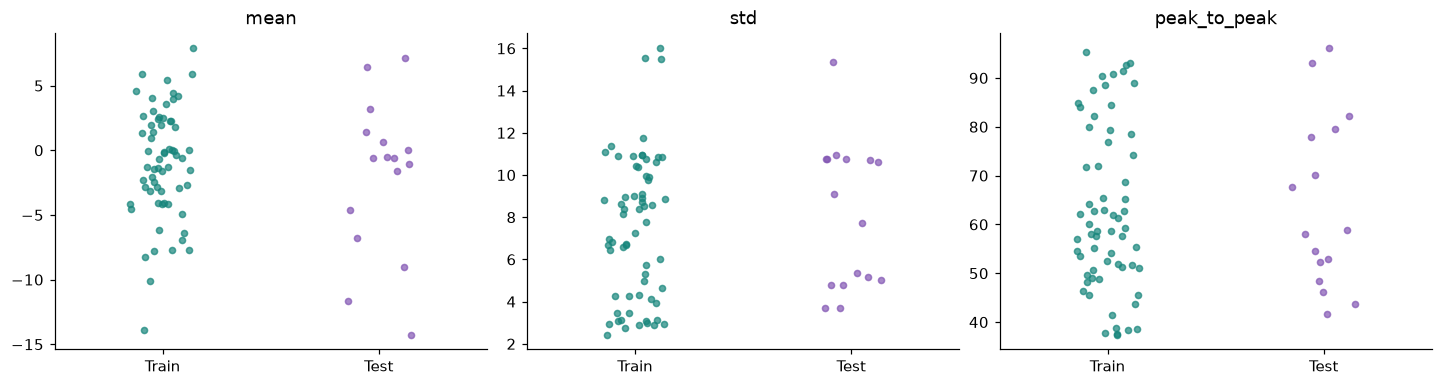

In [12]:
rng = np.random.default_rng(SEED)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, column in zip(axes, ['mean', 'std', 'peak_to_peak']):
    for i, split in enumerate(['Train', 'Test']):
        values = audit.loc[audit['dataset'].eq(split), column]
        ax.scatter(i + rng.uniform(-0.15, 0.15, len(values)), values, s=16, alpha=0.7, color=COLORS[split])
    ax.set(xticks=[0, 1], xticklabels=['Train', 'Test'], title=column, xlim=(-0.5, 1.5))
plt.show()

<blockquote><h3 id="3-7"><b>3.7 Sample Traces</b></h3></blockquote>

In the cell below, the first 2,000 samples of the Train recordings with the lowest, median and highest
damage are plotted on a shared scale.

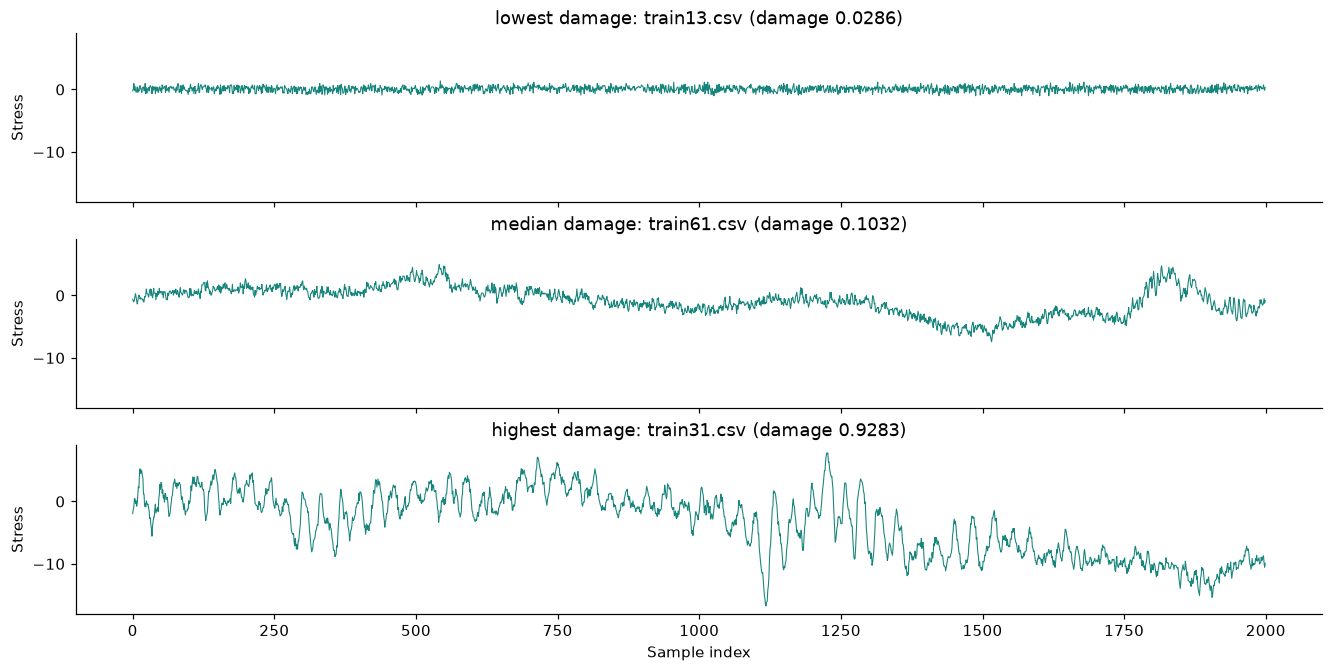

In [13]:
ranked = labels.sort_values()
chosen = {'lowest damage': ranked.index[0], 'median damage': ranked.index[len(ranked) // 2], 'highest damage': ranked.index[-1]}
fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True, sharey=True)
for ax, (title, name) in zip(axes, chosen.items()):
    ax.plot(recordings[name][:2000], color=COLORS['Train'], linewidth=0.7)
    ax.set(title=f'{title}: {name} (damage {labels[name]:.4f})', ylabel='Stress')
axes[-1].set_xlabel('Sample index')
plt.show()

<blockquote><h3 id="3-8"><b>3.8 Target Distribution</b></h3></blockquote>

In the cell below, the damage values are plotted on linear and logarithmic scales and summarised by
quartile band. The score depends on relative error, so the spread on the logarithmic scale is the
relevant one.

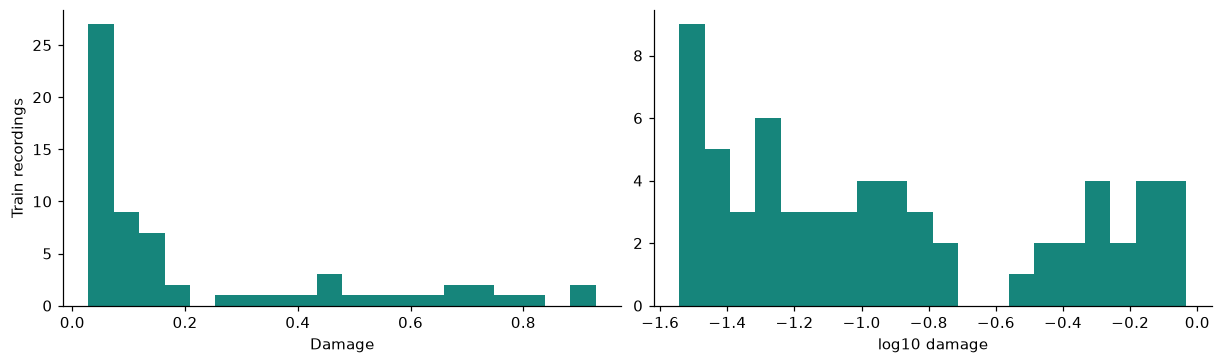

Damage range 0.028620 to 0.928339, ratio 32.4


,size,min,median,max
damage,,,,
Q1 low,16,0.0286,0.0338,0.0452
Q2,16,0.0461,0.0586,0.0947
Q3,16,0.1032,0.1372,0.3757
Q4 high,16,0.4236,0.6445,0.9283


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
axes[0].hist(labels, bins=20, color=COLORS['Train'])
axes[0].set(xlabel='Damage', ylabel='Train recordings')
axes[1].hist(np.log10(labels), bins=20, color=COLORS['Train'])
axes[1].set(xlabel='log10 damage')
plt.show()
print(f'Damage range {labels.min():.6f} to {labels.max():.6f}, ratio {labels.max() / labels.min():.1f}')
bands = pd.qcut(labels, 4, labels=['Q1 low', 'Q2', 'Q3', 'Q4 high'])
display(labels.groupby(bands, observed=True).agg(['size', 'min', 'median', 'max']).round(4))

<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-4" style="color: black;"><b>Section 4: Rainflow Cycle Extraction</b></h2>
</div>

This section counts stress cycles with the rainflow method, on the raw values and without smoothing,
detrending or resampling, because any such step would change the cycle ranges and so the damage sums.

<blockquote><h3 id="4-1"><b>4.1 Turning Points</b></h3></blockquote>

Rainflow counting depends only on the sequence of turning points (reversals). In the cell below, the
reversals of every recording are counted, and their share of the samples is reported.

In [15]:
audit['reversals'] = [sum(1 for _ in rainflow.reversals(recordings[n])) for n in audit['filename']]
audit['reversal_share'] = audit['reversals'] / audit['samples']
display(audit.groupby('dataset', sort=False)[['reversals', 'reversal_share']].agg(['min', 'median', 'max']).round(4))

reversals                   reversal_share                
              min    median     max            min  median     max
dataset                                                           
Train      317210  343389.0  367920         0.5459  0.5909  0.6331
Test       316475  343547.0  366303         0.5446  0.5912  0.6303

<blockquote><h3 id="4-2"><b>4.2 Cycle Counting</b></h3></blockquote>

In the cell below, `rainflow.extract_cycles` returns each cycle's range, mean and count, where a count
of 0.5 marks a half cycle from the unclosed residue. Cycles with identical range and mean are merged
with their counts summed, which shrinks the table without losing information. The number of full and
half cycles and the largest range are recorded per recording.

In [16]:
def count_cycles(x):
    """Rainflow cycles of one recording as an array of (range, mean, count) rows."""
    return np.array([(rng_, mean, count) for rng_, mean, count, _, _ in rainflow.extract_cycles(x)])


start = time.perf_counter()
file_order = list(audit['filename'])
cycle_parts, cycle_rows = [], []
for position, name in enumerate(file_order):
    c = count_cycles(recordings[name])
    cycle_rows.append({'filename': name, 'full_cycles': int((c[:, 2] == 1).sum()), 'half_cycles': int((c[:, 2] == 0.5).sum()),
                       'cycle_count': float(c[:, 2].sum()), 'max_range': float(c[:, 0].max())})
    merged = (pd.DataFrame({'range': c[:, 0], 'mean': c[:, 1], 'count': c[:, 2]})
              .groupby(['range', 'mean'], sort=False, as_index=False)['count'].sum())
    merged.insert(0, 'filename', pd.Categorical.from_codes(np.full(len(merged), position), categories=file_order))
    cycle_parts.append(merged)
cycles = pd.concat(cycle_parts, ignore_index=True)
audit = audit.merge(pd.DataFrame(cycle_rows), on='filename', validate='one_to_one')
print(f'Counted cycles in {time.perf_counter() - start:.0f} s; {len(cycles):,} distinct (range, mean) rows')
display(audit.groupby('dataset', sort=False)[['full_cycles', 'half_cycles', 'cycle_count']].agg(['min', 'median', 'max']))

Counted cycles in 85 s; 4,613,757 distinct (range, mean) rows


full_cycles                   half_cycles            cycle_count                    
                min    median     max         min median max         min    median       max
dataset                                                                                     
Train        158593  171680.5  183951          17   24.0  38    158604.5  171694.0  183959.5
Test         158229  171761.5  183141          15   24.0  38    158237.0  171773.0  183151.0

<blockquote><h3 id="4-3"><b>4.3 Cycle Count Validation</b></h3></blockquote>

Two identities must hold for a complete count. Each full cycle removes two reversals and the residue of
`k` reversals yields `k - 1` half cycles, so the reversals equal twice the full cycles plus the half
cycles plus one. The global maximum and minimum always form a counted range, so the largest range
equals the peak-to-peak range. In the cell below, both identities are checked for every recording.

In [17]:
audit['reversal_identity'] = audit['reversals'] == 2 * audit['full_cycles'] + audit['half_cycles'] + 1
audit['max_range_is_peak_to_peak'] = np.isclose(audit['max_range'], audit['peak_to_peak'])
display(audit.groupby('dataset', sort=False)[['reversal_identity', 'max_range_is_peak_to_peak']].agg(['sum', 'size']))
assert audit['reversal_identity'].all() and audit['max_range_is_peak_to_peak'].all()

reversal_identity      max_range_is_peak_to_peak     
                      sum size                       sum size
dataset                                                      
Train                  64   64                        64   64
Test                   16   16                        16   16

<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-5" style="color: black;"><b>Section 5: Feature Construction</b></h2>
</div>

This section builds three groups of per-recording features from the cycles and the raw values: damage
sums over a range of S-N exponents, the distribution of cycle ranges, and general signal statistics.
None of these steps uses labels.

<blockquote><h3 id="5-1"><b>5.1 Damage-Sum Features</b></h3></blockquote>

Under Miner's rule with an S-N curve `N = C / S^m`, damage is the sum of `n * S^m / C` over all cycles,
so the logarithm of damage equals the logarithm of the sum of `n * S^m` minus the logarithm of `C`. In
the cell below, the base-10 logarithm of that sum is computed for each exponent from 1 to 12, together
with the equivalent constant-amplitude range `(sum / N)^(1/m)`, where `N` is the total cycle count.
Ranges are used as `S`; using amplitudes would only change `C`.

In [18]:
def damage_sums(group):
    """log10 of sum(n * S^m) and the equivalent range for every exponent in M_VALUES."""
    ranges, counts = group['range'].to_numpy(), group['count'].to_numpy()
    total = counts.sum()
    out = {}
    for m in M_VALUES:
        weighted = float(np.sum(counts * ranges ** m))
        out[f'log10_dsum_m{m}'] = np.log10(weighted)
        out[f'eq_range_m{m}'] = (weighted / total) ** (1 / m)
    return pd.Series(out)


by_file = cycles.groupby('filename', observed=True)
damage_features = by_file[['range', 'count']].apply(damage_sums)
damage_features.index = damage_features.index.astype(str)
display(damage_features.iloc[:4, :6].round(4))

,log10_dsum_m1,eq_range_m1,log10_dsum_m2,eq_range_m2,log10_dsum_m3,eq_range_m3
filename,,,,,,
train01.csv,5.2799,1.0632,5.6436,1.5674,6.5139,2.6316
train02.csv,5.0558,0.6857,5.3816,1.2049,6.3757,2.4286
train03.csv,5.1795,0.8733,5.5067,1.3622,6.4145,2.4665
train04.csv,5.2753,1.0969,5.8655,2.0660,7.0706,4.0909


<blockquote><h3 id="5-2"><b>5.2 Range-Distribution Features</b></h3></blockquote>

In the cell below, the count-weighted quantiles of the cycle ranges (50th, 90th, 99th and 99.9th
percentiles) are computed per recording, together with the total cycle count and the number of half
cycles.

In [19]:
QUANTILES = {'range_p50': 0.5, 'range_p90': 0.9, 'range_p99': 0.99, 'range_p999': 0.999}


def range_quantiles(group):
    """Count-weighted quantiles of the cycle ranges of one recording."""
    order = np.argsort(group['range'].to_numpy())
    ranges, weights = group['range'].to_numpy()[order], group['count'].to_numpy()[order]
    cdf = np.cumsum(weights) / weights.sum()
    return pd.Series({name: ranges[np.searchsorted(cdf, q)] for name, q in QUANTILES.items()})


range_features = by_file[['range', 'count']].apply(range_quantiles)
range_features.index = range_features.index.astype(str)
range_features = range_features.join(audit.set_index('filename')[['cycle_count', 'half_cycles']])
display(range_features.head().round(4))

,range_p50,range_p90,range_p99,range_p999,cycle_count,half_cycles
filename,,,,,,
train01.csv,0.7802,2.0025,4.8762,13.1591,179168.0,26
train02.csv,0.4379,1.4159,4.3411,10.2128,165818.0,20
train03.csv,0.6505,1.7390,4.6727,11.3268,173099.0,24
train04.csv,0.7611,1.9601,7.8318,21.6672,171863.5,21
train05.csv,0.4379,1.1990,2.7084,7.3811,176329.5,23


<blockquote><h3 id="5-3"><b>5.3 Signal Statistics</b></h3></blockquote>

In the cell below, general statistics are computed from the raw values: mean, standard deviation,
peak-to-peak range, skewness, kurtosis, the RMS of the first difference, the rate of mean crossings and
of turning points per sample, and the spectral centroid. The sampling rate is unknown, so frequencies
are expressed in cycles per sample.

In [20]:
def signal_statistics(x, reversals):
    """Distribution, roughness and spectral summaries of one recording; frequency in cycles per sample."""
    centred = x - x.mean()
    freqs, power = signal.welch(x, fs=1.0, nperseg=4096)
    return {'mean': x.mean(), 'std': x.std(), 'peak_to_peak': np.ptp(x), 'skewness': stats.skew(x),
            'kurtosis': stats.kurtosis(x), 'diff_rms': np.sqrt(np.mean(np.diff(x) ** 2)),
            'mean_crossing_rate': np.mean(np.diff(np.sign(centred)) != 0),
            'turning_point_rate': reversals / len(x), 'spectral_centroid': (freqs * power).sum() / power.sum()}


signal_features = pd.DataFrame({name: signal_statistics(recordings[name], rev)
                                for name, rev in zip(audit['filename'], audit['reversals'])}).T
display(signal_features.head().round(5))

,mean,std,peak_to_peak,skewness,kurtosis,diff_rms,mean_crossing_rate,turning_point_rate,spectral_centroid
train01.csv,5.93508,8.63142,58.73498,-0.30433,0.01421,0.84182,0.04001,0.61663,0.01210
train02.csv,-7.73203,10.75398,62.94799,0.17938,0.74329,0.52475,0.03327,0.57069,0.00709
train03.csv,1.92678,9.01978,58.02439,-0.19160,0.66114,0.66924,0.08404,0.59574,0.00966
train04.csv,-2.47791,6.96985,92.58732,0.11238,0.20641,0.83504,0.04229,0.59149,0.01049
train05.csv,3.07460,8.83038,48.79372,0.07648,0.26078,0.47616,0.03323,0.60686,0.00645


<blockquote><h3 id="5-4"><b>5.4 Feature Table Assembly</b></h3></blockquote>

In the cell below, the three feature groups are joined into one row per recording with the damage
target and its base-10 logarithm, and the table is checked for missing and non-finite values.

In [21]:
features = (files.set_index('filename')[['dataset']].join(signal_features).join(range_features).join(damage_features))
features = features.apply(lambda c: pd.to_numeric(c) if c.name != 'dataset' else c)
FEATURES = [c for c in features.columns if c != 'dataset']
GROUPS = {'signal': list(signal_features.columns), 'range distribution': list(range_features.columns),
          'damage sum': [c for c in damage_features.columns if c.startswith('log10_dsum')],
          'equivalent range': [c for c in damage_features.columns if c.startswith('eq_range')]}
features['damage'] = features.index.map(labels)
features['log10_damage'] = np.log10(features['damage'])
print('Feature table:', features.shape, '| features:', len(FEATURES))
print('Missing or non-finite feature values:', int((~np.isfinite(features[FEATURES].to_numpy(dtype=float))).sum()))
if not features.index.is_unique or not np.isfinite(features[FEATURES].to_numpy(dtype=float)).all():
    raise ValueError('Features require unique IDs and finite numerical values.')


Feature table: (80, 42) | features: 39
Missing or non-finite feature values: 0


<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-6" style="color: black;"><b>Section 6: Target and Feature Relationships</b></h2>
</div>

This section screens how the constructed features relate to damage on the Train recordings, examines
the damage sums across S-N exponents, and checks whether the Test recordings fall inside the Train
feature ranges. The screens are descriptive; model selection belongs to the training notebook, under
the folds defined in Section 7.

<blockquote><h3 id="6-1"><b>6.1 Association Screen</b></h3></blockquote>

In the cell below, the Spearman rank correlation between every feature and damage is computed on the
Train recordings, and the fifteen strongest associations are listed by absolute value.

In [22]:
train = features[features['dataset'].eq('Train')]
test = features[features['dataset'].eq('Test')]
spearman = train[FEATURES].corrwith(train['damage'], method='spearman').rename('spearman')
display(spearman.reindex(spearman.abs().sort_values(ascending=False).index).head(15).round(4).to_frame())

,spearman
eq_range_m5,0.9983
log10_dsum_m5,0.9982
eq_range_m6,0.9908
log10_dsum_m6,0.9902
eq_range_m7,0.9862
log10_dsum_m7,0.9862
eq_range_m8,0.9833
log10_dsum_m8,0.9830
log10_dsum_m9,0.9800
eq_range_m9,0.9796


<blockquote><h3 id="6-2"><b>6.2 Damage-Sum Exponent Profile</b></h3></blockquote>

If Miner's rule with exponent `m` produced the labels, the logarithm of damage would be a straight line
of slope 1 in the logarithm of the damage sum, with a correlation close to 1. In the cell below, the
Pearson correlation and the least-squares slope of log damage on log damage sum are computed for every
exponent and plotted.

,pearson_r,slope,intercept,spearman
m,,,,
1,0.2197,1.6692,-9.5030,0.1718
2,0.7237,2.2439,-13.2732,0.7189
3,0.9120,1.5967,-11.2596,0.8515
4,0.9873,1.2709,-10.9285,0.9725
5,0.9994,0.9965,-10.3349,0.9982
6,0.9961,0.8022,-9.8204,0.9902
7,0.9911,0.6681,-9.4601,0.9862
8,0.9868,0.5720,-9.2085,0.9830
9,0.9832,0.4999,-9.0262,0.9800


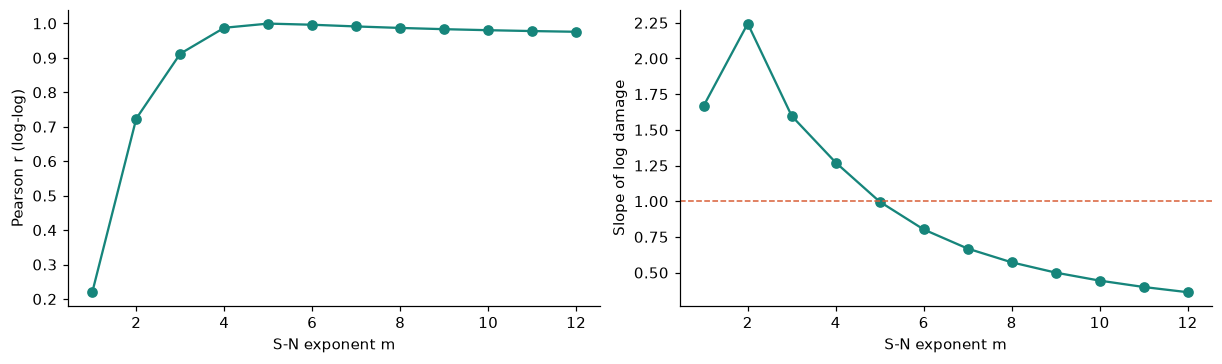

In [23]:
profile_rows = []
for m in M_VALUES:
    fit = stats.linregress(train[f'log10_dsum_m{m}'], train['log10_damage'])
    profile_rows.append({'m': m, 'pearson_r': fit.rvalue, 'slope': fit.slope, 'intercept': fit.intercept,
                         'spearman': stats.spearmanr(train[f'log10_dsum_m{m}'], train['damage']).statistic})
profile = pd.DataFrame(profile_rows).set_index('m')
display(profile.round(4))
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
axes[0].plot(profile.index, profile['pearson_r'], 'o-', color=COLORS['Train'])
axes[0].set(xlabel='S-N exponent m', ylabel='Pearson r (log-log)')
axes[1].plot(profile.index, profile['slope'], 'o-', color=COLORS['Train'])
axes[1].axhline(1, color=COLORS['accent'], linewidth=1, linestyle='--')
axes[1].set(xlabel='S-N exponent m', ylabel='Slope of log damage')
plt.show()

<blockquote><h3 id="6-3"><b>6.3 Train and Test Range Comparison</b></h3></blockquote>

In the cell below, the number of Test recordings outside the Train range is counted for every feature
and summarised by feature group, and the individual features with out-of-range Test values are listed.
Extrapolating a power law beyond the Train range is where relative errors grow fastest.

In [24]:
outside = pd.Series({f: int(((test[f] < train[f].min()) | (test[f] > train[f].max())).sum()) for f in FEATURES})
display(pd.DataFrame({group: {'features': len(cols), 'features with Test outside Train range': int((outside[cols] > 0).sum())}
                      for group, cols in GROUPS.items()}).T)
display(outside[outside > 0].sort_values(ascending=False).rename('Test recordings outside Train range').to_frame())

,features,features with Test outside Train range
signal,9,6
range distribution,6,2
damage sum,12,0
equivalent range,12,0


,Test recordings outside Train range
half_cycles,2
mean,1
skewness,1
peak_to_peak,1
kurtosis,1
turning_point_rate,1
spectral_centroid,1
cycle_count,1


<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-7" style="color: black;"><b>Section 7: Validation Folds</b></h2>
</div>

This section assigns fixed validation folds to the Train recordings so that every model is compared on
the same splits, with each fold covering the full damage range.

<blockquote><h3 id="7-1"><b>7.1 Damage-Band Folds</b></h3></blockquote>

Four deterministic damage-band folds keep exact numerical duplicates together. Conflicting labels on identical signals stop execution. Target bands, hashes and fold IDs are metadata only, never predictors. Input ordering does not change membership. Unknown line/load/session dependence remains a limitation. No learned preprocessing is fitted here.

In [25]:
train_index = features.index[features['dataset'].eq('Train')]
fold_manifest = assign_folds(features.loc[train_index, 'damage'],
    audit.set_index('filename').loc[train_index, 'values_sha256'], seed=SEED)
for column in ['damage_band', 'fold']:
    features[column] = pd.Series(pd.NA, index=features.index, dtype='Int64')
    features.loc[train_index, column] = fold_manifest[column]
assert features.loc[features['dataset'].eq('Test'), ['fold', 'damage_band']].isna().all().all()
assert fold_manifest.groupby('group_id')['fold'].nunique().eq(1).all()
display(pd.crosstab(fold_manifest['fold'], fold_manifest['damage_band'], margins=True))
display(fold_manifest.groupby('fold')['damage'].agg(['size', 'min', 'median', 'max']).round(4))


damage_band,0,1,2,3,All
fold,,,,,
0,4,4,4,4,16
1,4,4,4,4,16
2,4,4,4,4,16
3,4,4,4,4,16
All,16,16,16,16,64


,size,min,median,max
fold,,,,
0,16,0.0340,0.1134,0.7896
1,16,0.0286,0.0910,0.7165
2,16,0.0288,0.0797,0.8947
3,16,0.0286,0.0960,0.9283


<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-8" style="color: black;"><b>Section 8: Export</b></h2>
</div>

This section writes the prepared tables to Parquet, records a manifest of settings and sources, and
verifies that every file reads back identically.

<blockquote><h3 id="8-1"><b>8.1 Output Tables</b></h3></blockquote>

Retain the audit, combined features and rainflow cycles for inspection. Export separate X_train, y_train, X_test and fold-manifest tables keyed by filename. Only the explicit feature allowlist enters X. Targets, log targets, bands, groups and folds remain outside the predictor matrix. Keep features unscaled; fit learned transformations inside training folds. Filenames identify rows and are not model inputs.

In [26]:
def for_parquet(frame):
    """Copy of `frame` with a fresh index and object columns converted to the pandas string dtype."""
    out = frame.reset_index(drop=True).copy()
    for column in out.columns[out.dtypes.eq(object)]:
        out[column] = out[column].astype('string')
    return out


audit_out = audit.join(features[['damage', 'log10_damage', 'damage_band', 'fold']], on='filename')
outputs = {
    'shm_files.parquet': for_parquet(audit_out),
    'shm_features.parquet': for_parquet(features.rename_axis('filename').reset_index()),
    'shm_cycles.parquet': for_parquet(cycles),
}
outputs.update({name: for_parquet(frame) for name, frame in training_tables(features, FEATURES, fold_manifest).items()})
for name, frame in outputs.items():
    frame.to_parquet(OUT_DIR / name, index=False)
display(pd.DataFrame([{'file': name, 'rows': len(frame), 'columns': frame.shape[1],
                       'size_MB': round((OUT_DIR / name).stat().st_size / 1e6, 2)} for name, frame in outputs.items()]))

,file,rows,columns,size_MB
0,shm_files.parquet,80,28,0.04
1,shm_features.parquet,80,45,0.06
2,shm_cycles.parquet,4613757,4,49.45
3,X_train.parquet,64,40,0.05
4,y_train.parquet,64,3,0.00
5,X_test.parquet,16,40,0.03
6,fold_manifest.parquet,64,5,0.01


<blockquote><h3 id="8-2"><b>8.2 Manifest</b></h3></blockquote>

In the cell below, a JSON manifest records the source fingerprints, the settings, the feature groups and
the size of each output.

In [27]:
manifest = {
    'subsystem': 'SHM',
    'sources': dict(zip(files['filename'], files['sha256'])) | {
        'Train_Labels.csv': hashlib.sha256((SHM_DIR / 'Train_Labels.csv').read_bytes()).hexdigest()},
    'settings': {'seed': SEED, 'rainflow': importlib.metadata.version('rainflow'),
                 'cycle_input': 'raw values; no smoothing, detrending or resampling',
                 'half_cycle_count': 0.5, 'stress_measure': 'cycle range', 'exponents': M_VALUES,
                 'spectral_units': 'cycles per sample (Welch, nperseg 4096)',
                 'folds': 'shm-group-bands-v2: deterministic target bands; numerical duplicates grouped'},
    'feature_groups': GROUPS,
    'feature_columns': FEATURES,
    'feature_version': 'shm-rainflow-v1',
    'contract_version': 'shm-training-v2',
    'versions': versions,
    'training_contract': {'key': 'filename', 'target': 'damage', 'log_target': 'log10_damage',
                          'learned_preprocessing': 'training folds only', 'test_targets': 'unknown'},
    'outputs': {name: {'rows': len(frame), 'columns': frame.shape[1], 'sha256': hashlib.sha256((OUT_DIR / name).read_bytes()).hexdigest()} for name, frame in outputs.items()},
}
(OUT_DIR / 'manifest.json').write_text(json.dumps(manifest, indent=2))
print(json.dumps(manifest['settings'], indent=2))

{
  "seed": 2026,
  "rainflow": "3.2.0",
  "cycle_input": "raw values; no smoothing, detrending or resampling",
  "half_cycle_count": 0.5,
  "stress_measure": "cycle range",
  "exponents": [
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    10,
    11,
    12
  ],
  "spectral_units": "cycles per sample (Welch, nperseg 4096)",
  "folds": "shm-group-bands-v2: deterministic target bands; numerical duplicates grouped"
}


<blockquote><h3 id="8-3"><b>8.3 Export Verification</b></h3></blockquote>

In the cell below, each Parquet file is read back and compared with the table in memory.

In [28]:
for name, frame in outputs.items():
    pd.testing.assert_frame_equal(pd.read_parquet(OUT_DIR / name), frame)
print('All outputs read back identically.')

All outputs read back identically.


<blockquote><h3 id="8-4"><b>8.4 Training Handoff and Leakage Checks</b></h3></blockquote>

Reload the separate exports and create fold 0 training/validation partitions without fitting a model. Repeat for all folds during training. The manifest feature allowlist defines predictors; do not take every numeric column from the combined inspection table.

In [29]:
X_train = pd.read_parquet(OUT_DIR / 'X_train.parquet').set_index('filename')
y_train = pd.read_parquet(OUT_DIR / 'y_train.parquet').set_index('filename')
X_test = pd.read_parquet(OUT_DIR / 'X_test.parquet').set_index('filename')
folds = pd.read_parquet(OUT_DIR / 'fold_manifest.parquet').set_index('filename')
assert X_train.index.equals(y_train.index) and X_train.index.equals(folds.index)
assert list(X_train.columns) == list(X_test.columns) == FEATURES
assert not set(X_train.index).intersection(X_test.index)
validation_mask = folds['fold'].eq(0)
X_fit, X_valid = X_train.loc[~validation_mask], X_train.loc[validation_mask]
y_fit, y_valid = y_train.loc[~validation_mask, 'damage'], y_train.loc[validation_mask, 'damage']
assert not set(folds.loc[~validation_mask, 'group_id']).intersection(folds.loc[validation_mask, 'group_id'])
display(pd.DataFrame({'rows': [len(X_fit), len(X_valid), len(X_test)],
                      'predictors': [X_fit.shape[1], X_valid.shape[1], X_test.shape[1]]},
                     index=['Fold 0 training', 'Fold 0 validation', 'Unlabelled Test']))
print('Training handoff verified; no estimator fitted and no Test targets assigned.')


,rows,predictors
Fold 0 training,48,39
Fold 0 validation,16,39
Unlabelled Test,16,39


Training handoff verified; no estimator fitted and no Test targets assigned.


<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-9" style="color: black;"><b>Section 9: Conclusions</b></h2>
</div>

This section summarises the prepared outputs, the data-quality findings, and their implications for
model training. All statements refer to the executed results above.

<blockquote><h3 id="9-1"><b>9.1 Prepared Outputs</b></h3></blockquote>

- shm_files.parquet: source/numerical fingerprints, signal audits and cycle summaries.
- shm_features.parquet: combined feature table for inspection, including Train targets and metadata.
- shm_cycles.parquet: merged rainflow ranges, means and counts.
- X_train.parquet / y_train.parquet: separate filename-aligned predictors and targets.
- X_test.parquet: identical predictor schema with no targets or fold metadata.
- fold_manifest.parquet: Train-only recording groups, damage bands and validation folds.
- manifest.json: source/output hashes, versions, feature allowlist and training contract.

Use the executed tables above for actual dimensions. All Parquet files are read back and checked.

<blockquote><h3 id="9-2"><b>9.2 Data Quality Findings</b></h3></blockquote>

The checks enforce complete file/label coverage, positive finite targets, single-channel finite non-constant
signals, equal recording lengths and finite features. Invalid data stops execution instead of being
silently repaired. Large stress excursions are retained. Exact duplicates remain in one fold;
Train/Test overlaps are reported for review. No smoothing, interpolation, clipping, resampling
or global standardisation is applied. Stress units, sampling frequency and source-session metadata remain unknown.

<blockquote><h3 id="9-3"><b>9.3 Implications for Modelling</b></h3></blockquote>

Rainflow damage sums are candidate features, not calibrated damage predictions. The full-Train association
and exponent screens are descriptive only: selecting exponents, thresholds or feature subsets requires
training-fold-only selection. Strong correlation and univariate Test coverage do not prove generalisation.

Fit any scaler, imputer, feature selector and estimator within each training fold. Evaluate log-target
models after transforming predictions back with 10 ** prediction, using max(0, 1 - MAPE).
Use the same fold manifest for comparisons. Unknown line/load/session dependence limits validation.
This notebook trains no estimator and assigns no Test targets. Healthy-condition cumulative-damage
labels do not validate structural-fault classification or remaining useful life.